In [1]:
import sqlite3
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np

DB = '../data/humans_clean.sqlite3'
conn = sqlite3.connect(DB)
conn.execute('PRAGMA cache_size=-500000')

# Law-related occupation keywords to match in occupations_en
law_keywords = [
    'lawyer', 'jurist', 'judge', 'magistrate', 'barrister',
    'notary', 'legal scholar', 'prosecutor', 'solicitor',
    'advocate', 'attorney',
]
# Build SQL: individual has at least one law occupation
law_conditions = ' OR '.join(f"i.occupations_en LIKE '%{kw}%'" for kw in law_keywords)

# Three countries, chaining polities across eras
countries = [
    ('United States', [
        ("ic.polity_name LIKE 'United States of America%'", 1776, 2024),
    ]),
    ('France', [
        ("ic.polity_name LIKE '%Kingdom of France%'", None, None),
        ("ic.polity_name = 'French First Republic'", None, None),
        ("ic.polity_name LIKE '%First French Empire%'", None, None),
        ("ic.polity_name LIKE '%Bourbon Kingdom of France%'", None, None),
        ("ic.polity_name LIKE '%Second French Empire%'", None, None),
        ("ic.polity_name LIKE '%French Third Republic%'", None, None),
        ("ic.polity_name = 'French Fourth Republic'", None, None),
        ("ic.polity_name = 'French Fifth Republic'", None, None),
        ("ic.polity_name = 'Vichy France'", None, None),
    ]),
    ('China', [
        ("ic.polity_name LIKE '%Ming Dynasty%'", None, None),
        ("ic.polity_name LIKE '%Qing Dynasty%'", None, None),
        ("ic.polity_name = 'Republic of China'", None, None),
        ("ic.polity_name = 'People\\''s Republic of China'", None, None),
    ]),
]

bin_w = 10
country_data = []

for country_label, polity_list in countries:
    # Combine all polity WHERE clauses with OR
    combined_where = ' OR '.join(f'({w})' for w, _, _ in polity_list)

    # Law individuals per bin
    law_rows = conn.execute(f'''
        SELECT (ic.floruit_period_start / {bin_w}) * {bin_w} as time_bin,
               COUNT(DISTINCT ic.wikidata_id) as n
        FROM individuals_cliopatria ic
        JOIN individuals i ON ic.wikidata_id = i.wikidata_id
        WHERE ({combined_where})
          AND ({law_conditions})
          AND ic.floruit_period_start IS NOT NULL
        GROUP BY time_bin
    ''').fetchall()
    law_map = {r[0]: r[1] for r in law_rows}

    # Total individuals per bin
    tot_rows = conn.execute(f'''
        SELECT (ic.floruit_period_start / {bin_w}) * {bin_w} as time_bin,
               COUNT(DISTINCT ic.wikidata_id) as n
        FROM individuals_cliopatria ic
        WHERE ({combined_where})
          AND ic.floruit_period_start IS NOT NULL
        GROUP BY time_bin
    ''').fetchall()
    tot_map = {r[0]: r[1] for r in tot_rows}

    # Get overall year range from data
    yr_range = conn.execute(f'''
        SELECT MIN(ic.floruit_period_start), MAX(ic.floruit_period_start)
        FROM individuals_cliopatria ic
        WHERE ({combined_where}) AND ic.floruit_period_start IS NOT NULL
    ''').fetchone()

    all_bins = sorted(tot_map.keys())
    # Drop last partial bucket
    last_full = (yr_range[1] // bin_w) * bin_w - bin_w
    f_bins, f_pct, f_law, f_tot = [], [], [], []
    for b in all_bins:
        if b <= last_full:
            total = tot_map.get(b, 0)
            law = law_map.get(b, 0)
            if total > 0:
                f_bins.append(b)
                f_pct.append(law / total * 100)
                f_law.append(law)
                f_tot.append(total)

    country_data.append((country_label, f_bins, f_pct, f_law, f_tot))
    print(f"{country_label}: {f_bins[0]}–{f_bins[-1]}, {len(f_bins)} bins, "
          f"total law={sum(f_law):,}, total indiv={sum(f_tot):,}")

conn.close()

United States: 1700–2010, 28 bins, total law=32,711, total indiv=560,608


France: 900–2010, 108 bins, total law=14,137, total indiv=347,227


China: 1300–2010, 67 bins, total law=225, total indiv=65,885


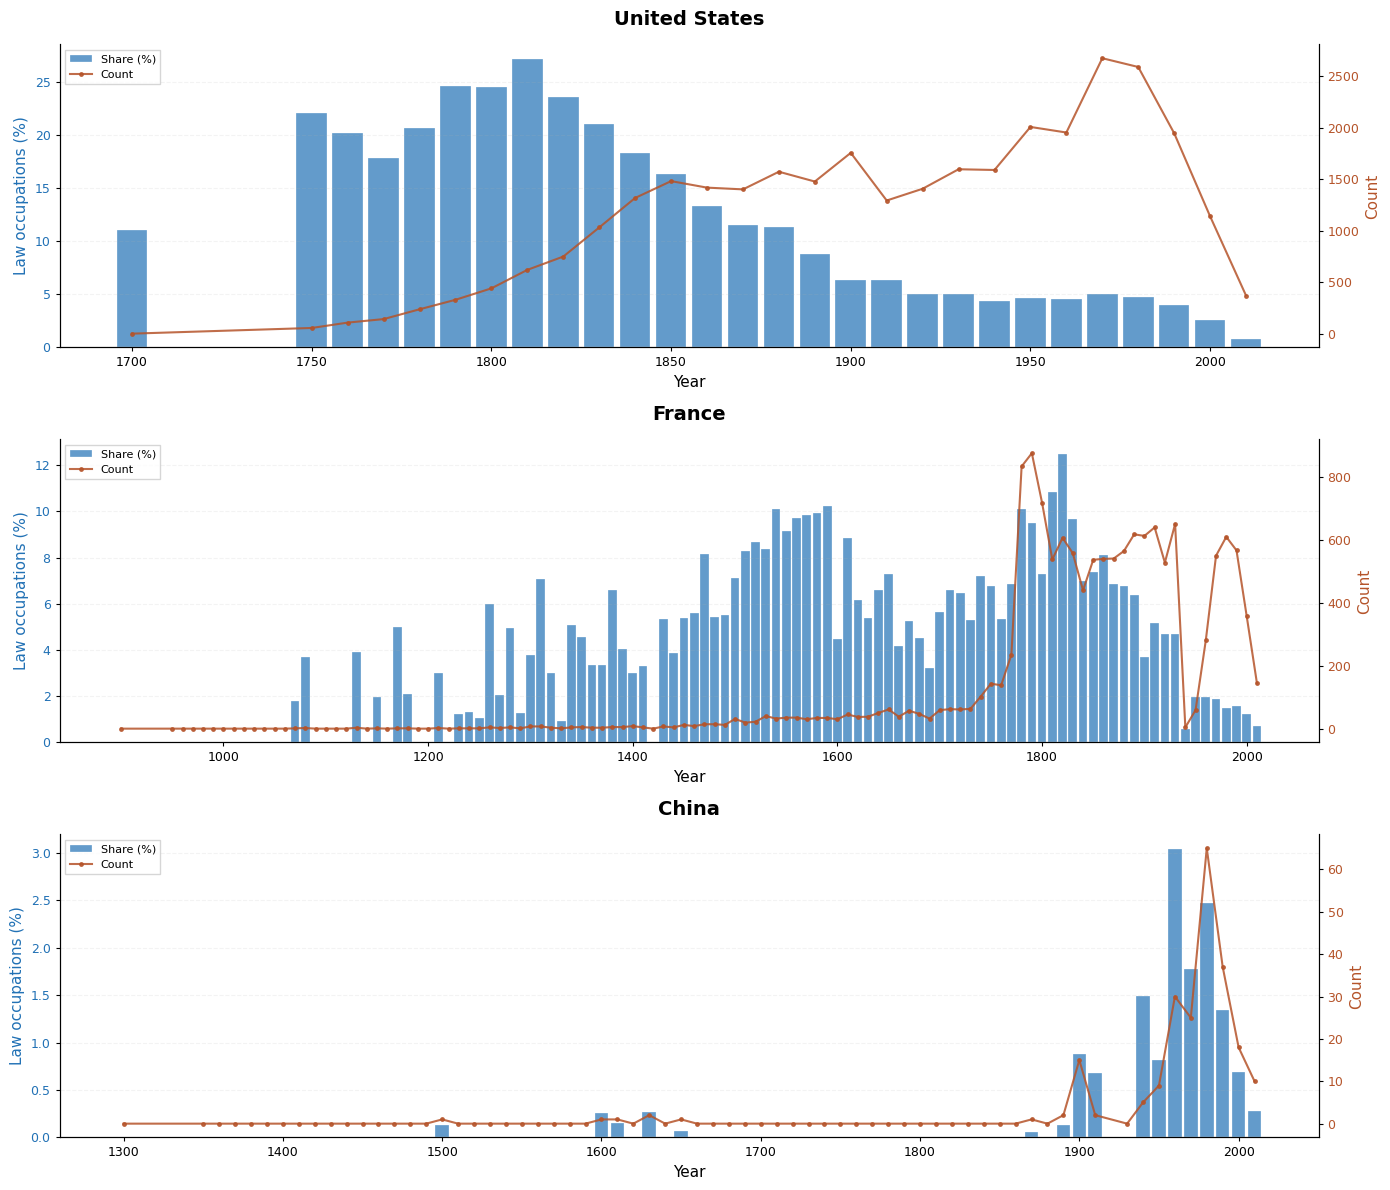

In [2]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)

color_pct = '#2171b5'
color_abs = '#b5542a'

for idx, (label, bins, pcts, law_counts, tot_counts) in enumerate(country_data):
    ax = axes[idx]
    ax2 = ax.twinx()

    # Percentage as bars
    ax.bar(bins, pcts, width=bin_w * 0.85, color=color_pct,
           edgecolor='white', linewidth=0.3, alpha=0.7, label='Share (%)')

    # Absolute count as line on secondary axis
    ax2.plot(bins, law_counts, '-o', color=color_abs, linewidth=1.5,
             markersize=2.5, alpha=0.85, label='Count')

    ax.set_title(label, fontsize=14, fontweight='bold', color='black',
                 loc='center', pad=14)
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('Law occupations (%)', fontsize=11, color=color_pct)
    ax2.set_ylabel('Count', fontsize=11, color=color_abs)
    ax.tick_params(axis='y', labelcolor=color_pct)
    ax2.tick_params(axis='y', labelcolor=color_abs)

    ax.spines['top'].set_visible(False)
    ax2.spines['top'].set_visible(False)
    ax.tick_params(axis='both', which='both', length=3, labelsize=9)
    ax2.tick_params(axis='both', which='both', length=3, labelsize=9)
    ax.grid(axis='y', alpha=0.15, linestyle='--')

    # Combined legend
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper left',
              frameon=True, fancybox=False, edgecolor='#cccccc')

plt.tight_layout()
plt.show()